In [331]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [332]:
data_path = os.path.join(*Path.cwd().parts[:-1],"data")

**Read in data from csv files**

In [333]:
df = pd.DataFrame()
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        temp_df = pd.read_csv(file_path)
        df = pd.concat([df, temp_df], ignore_index=True)
len(df)

4440384

In [334]:
df.head(10)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,2023-01-31 14:00:01,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,2023-01-31 14:00:02,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,2023-01-31 14:00:03,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,2023-01-31 14:00:04,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,2023-01-31 14:00:05,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250
5,2023-01-31 14:00:06,0.000205,0.000166,0.000149,19.791374,19.863214,19.958219,19.611355,19.782754,19.910986,19.686506,19.866983,19.779079,19.822659,20.084014,20.555750,56.515500
6,2023-01-31 14:00:07,0.000207,0.000166,0.000149,19.791391,19.863192,19.958266,19.611362,19.782839,19.910973,19.686427,19.866940,19.779043,19.822784,20.084038,20.554000,56.531250
7,2023-01-31 14:00:08,0.000204,0.000166,0.000149,19.791472,19.863189,19.958201,19.611344,19.782866,19.910877,19.686598,19.866845,19.779098,19.822806,20.084124,20.555750,56.514750
8,2023-01-31 14:00:09,0.000206,0.000166,0.000148,19.791444,19.863215,19.958139,19.611246,19.782896,19.910850,19.686901,19.866846,19.779024,19.822787,20.084177,20.551750,56.517125
9,2023-01-31 14:00:10,0.000205,0.000166,0.000149,19.791392,19.863227,19.958176,19.611274,19.782966,19.910889,19.687056,19.866805,19.778983,19.822764,20.084140,20.552250,56.520000


Convert date to timestamp.

In [335]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M:%S')

#Comvert date to seconds since epoch
df['Date'] = df['Date'].astype('int64')//10**6

In [336]:
df.head(5)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,1675173601,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,1675173602,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,1675173603,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,1675173604,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,1675173605,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250


In [337]:
df = df.sort_values('Date').reset_index(drop=True)

In [338]:
import matplotlib.pyplot as plt

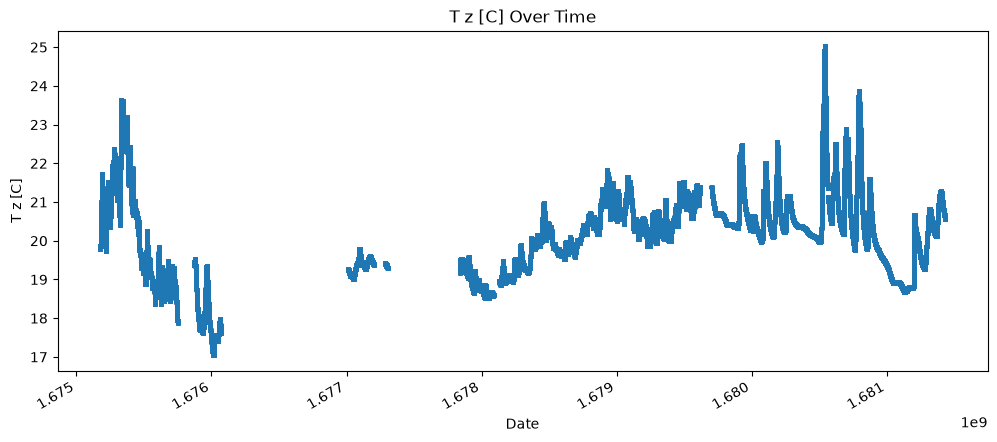

In [339]:
plt.figure(figsize=(12, 5))
plt.scatter(df['Date'], df['T z [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T z [C]")
plt.title("T z [C] Over Time")
plt.gcf().autofmt_xdate()  # angles the date labels so they don't overlap
plt.show()

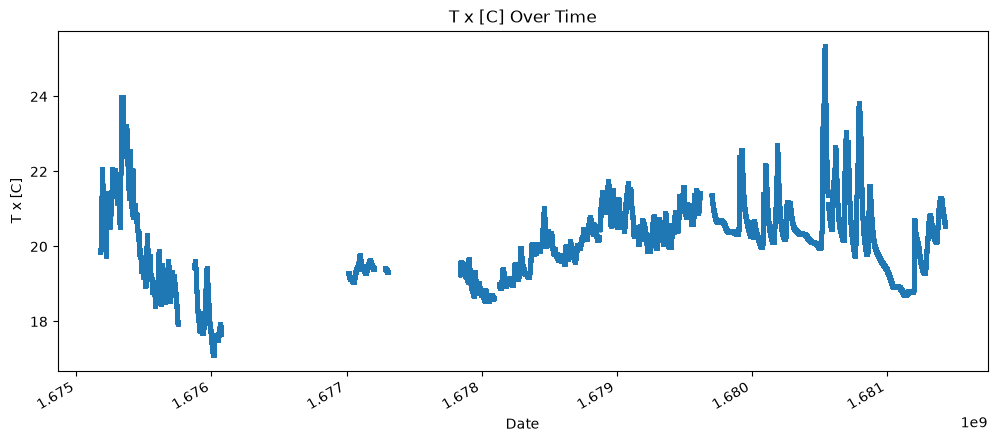

In [340]:
plt.figure(figsize=(12, 5))
plt.scatter(df['Date'], df['T x [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T x [C]")
plt.title("T x [C] Over Time")
plt.gcf().autofmt_xdate()  # angles the date labels so they don't overlap
plt.show()

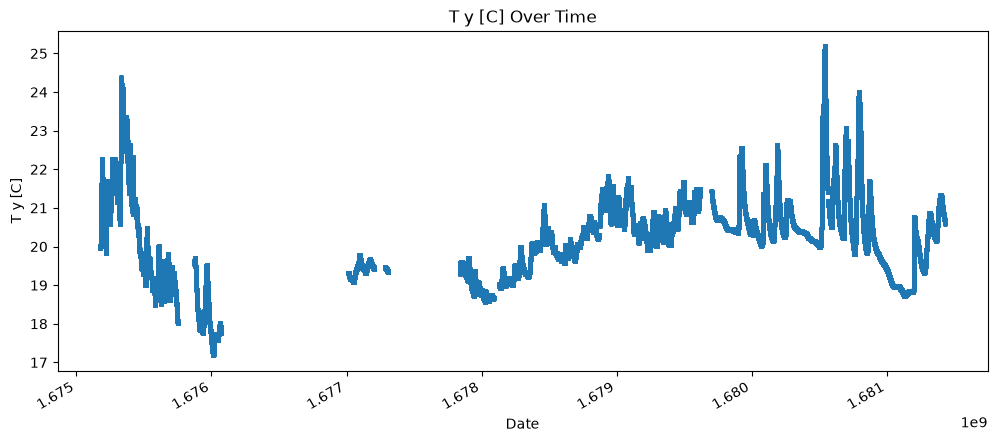

In [341]:
plt.figure(figsize=(12, 5))
plt.scatter(df['Date'], df['T y [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T y [C]")
plt.title("T y [C] Over Time")
plt.gcf().autofmt_xdate()  # angles the date labels so they don't overlap
plt.show()

Determine chunks of data that are uninterrupted.

In [342]:
times = df['Date'].values

best_start, best_end = 0, 0
last_idx = 0

for idx in range(1, len(times)):
    if times[idx] - times[idx - 1] > 1:
        if idx - last_idx > best_end - best_start:
            best_start, best_end = last_idx, idx
            print(f'New longest run len: {best_end - best_start}')
        last_idx = idx

# check the run still in progress when the loop ends
if len(times) - last_idx > best_end - best_start:
    best_start, best_end = last_idx, len(times)
    print(f'New longest run len: {best_end - best_start}')

uninterrupted_df = df[best_start:best_end]
        

New longest run len: 269
New longest run len: 4334
New longest run len: 7491
New longest run len: 14438
New longest run len: 17837
New longest run len: 70368
New longest run len: 70795
New longest run len: 90599
New longest run len: 252000
New longest run len: 739720
New longest run len: 746265


In [343]:
uninterrupted_df.drop(columns='Altitude [m]', inplace=True)
uninterrupted_df.head(10)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C]
1967042,1678873335,-0.000255,0.000015,0.000027,20.343941,20.452242,20.536662,20.454394,20.840455,21.149750,20.576104,20.980258,20.775696,21.235692,21.021573,20.779997
1967043,1678873336,-0.000258,0.000015,0.000026,20.344488,20.452119,20.536670,20.454457,20.839291,21.149834,20.576155,20.980214,20.775706,21.235638,21.021625,20.784550
1967044,1678873337,-0.000258,0.000015,0.000026,20.344734,20.452174,20.536654,20.454648,20.838908,21.149494,20.576266,20.979903,20.775798,21.234698,21.021522,20.789950
1967045,1678873338,-0.000257,0.000015,0.000026,20.344861,20.452265,20.536711,20.454957,20.838893,21.149110,20.576554,20.979604,20.775955,21.233754,21.021452,20.790000
1967046,1678873339,-0.000258,0.000014,0.000026,20.344875,20.452364,20.536803,20.455168,20.838885,21.148781,20.576778,20.979453,20.775926,21.232783,21.021507,20.790000
1967047,1678873340,-0.000256,0.000014,0.000026,20.344939,20.452622,20.536942,20.455435,20.839091,21.148548,20.577267,20.979315,20.775972,21.231861,21.021581,20.787250
1967048,1678873341,-0.000257,0.000014,0.000027,20.345094,20.452741,20.537126,20.455811,20.839236,21.148320,20.577427,20.979191,20.776113,21.230930,21.021564,20.788750
1967049,1678873342,-0.000258,0.000015,0.000026,20.345158,20.452818,20.537104,20.456032,20.839469,21.147980,20.577619,20.978906,20.776156,21.230071,21.021545,20.792625
1967050,1678873343,-0.000257,0.000014,0.000027,20.345339,20.452928,20.537181,20.456352,20.839468,21.147686,20.577954,20.978667,20.776228,21.229101,21.021564,20.801875
1967051,1678873344,-0.000258,0.000014,0.000026,20.345431,20.453102,20.537346,20.456736,20.839564,21.147560,20.578284,20.978576,20.776275,21.228209,21.021675,20.807750


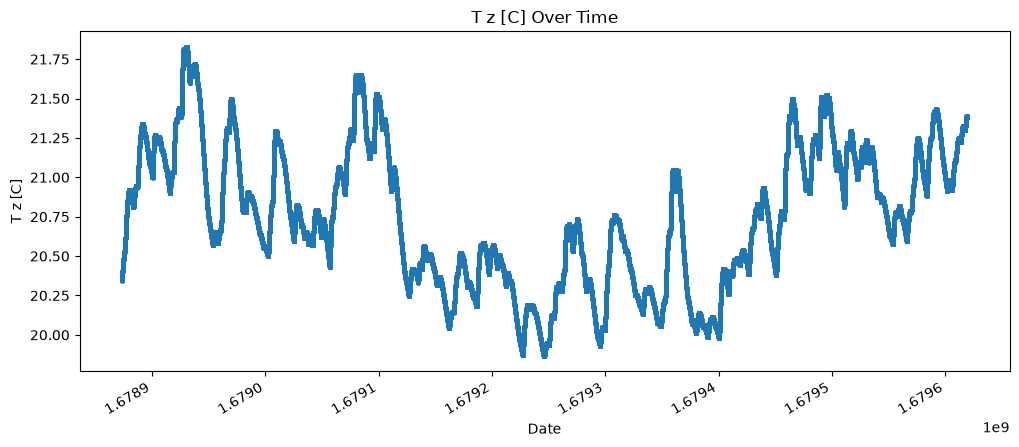

In [344]:
plt.figure(figsize=(12, 5))
plt.scatter(uninterrupted_df['Date'], uninterrupted_df['T z [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T z [C]")
plt.title("T z [C] Over Time")
plt.gcf().autofmt_xdate()  # angles the date labels so they don't overlap
plt.show()

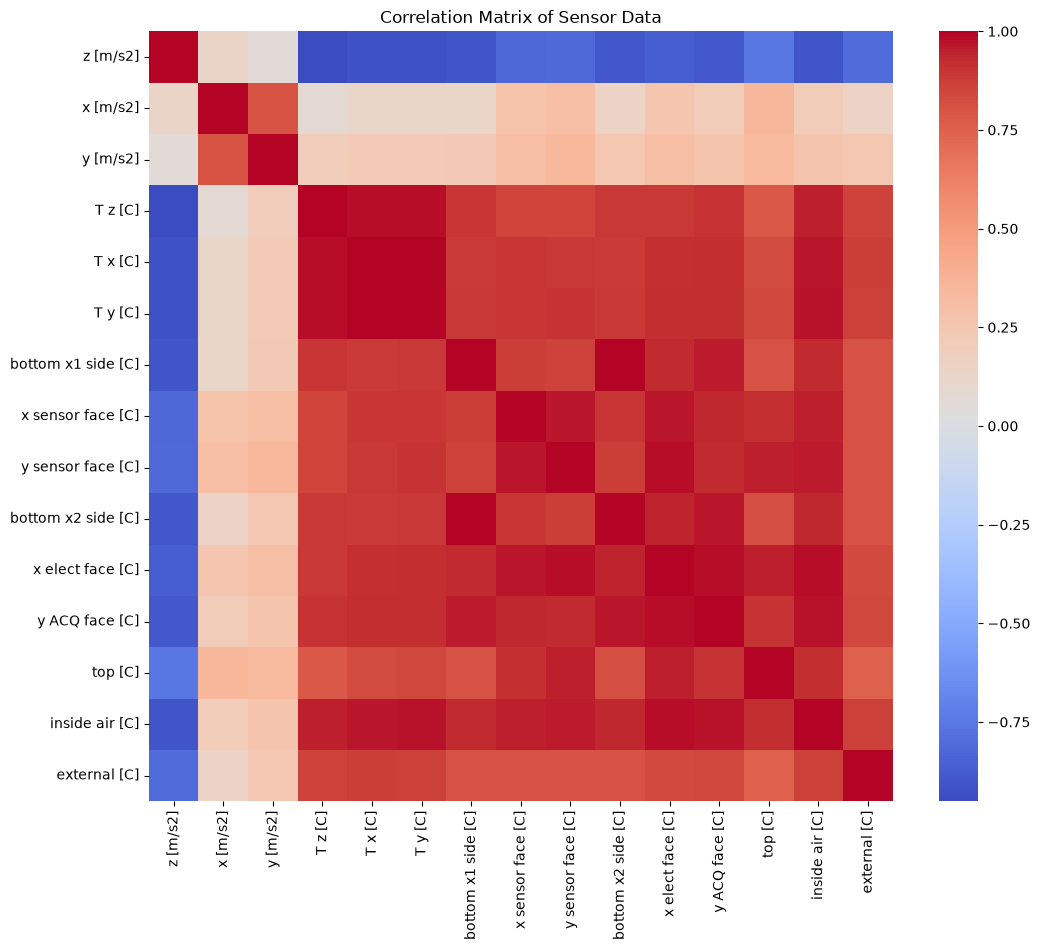

In [345]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix_df = uninterrupted_df.drop(columns='Date')
# Generate a correlation matrix
corr_matrix = matrix_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Sensor Data")
plt.show()

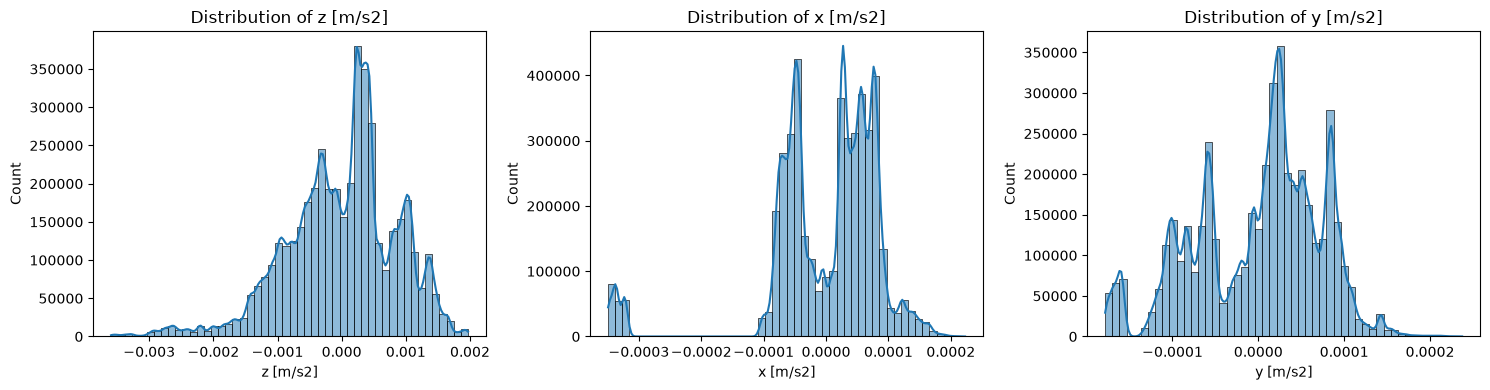

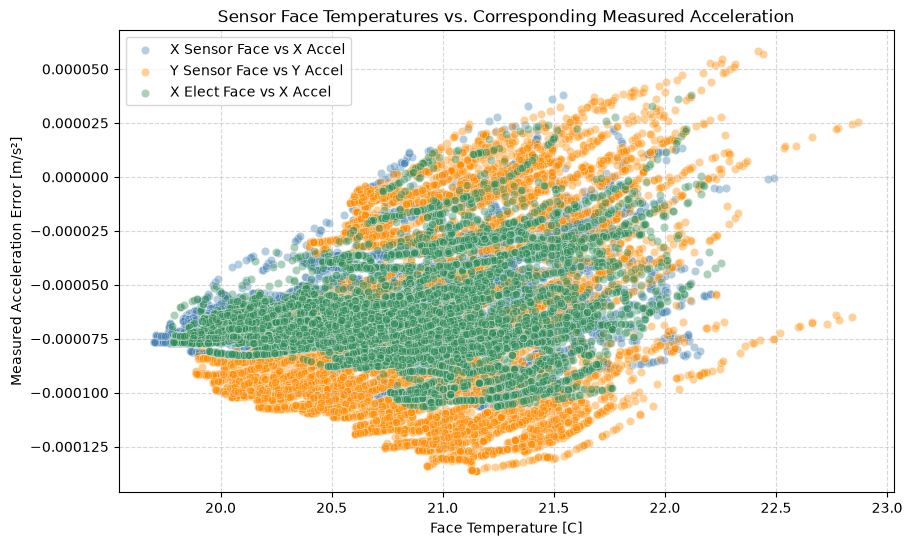

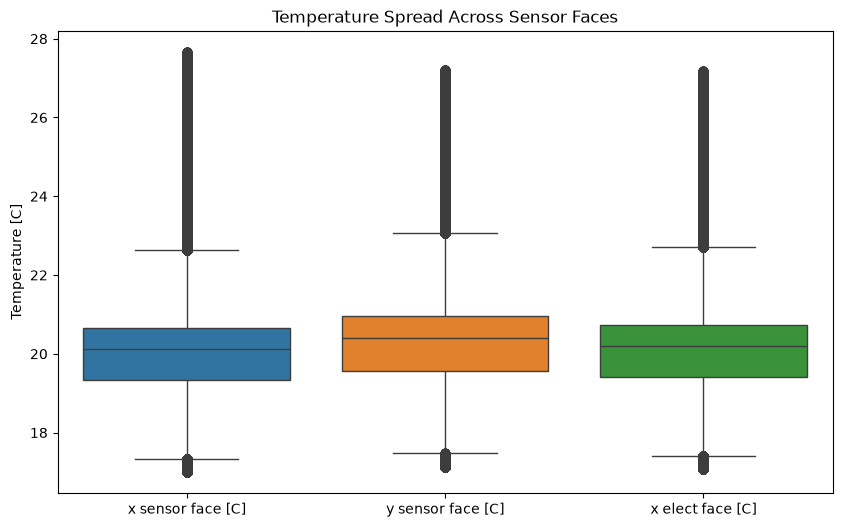

In [346]:
# Histograms of the target error distributions
target_cols = ['z [m/s2]', 'x [m/s2]', 'y [m/s2]']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(target_cols):
    sns.histplot(df[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

"""# Scatterplot showing relationship between external temp and internal air temp
plt.figure(figsize=(8, 5))
sns.scatterplot(x='external [C]', y='inside air [C]', data=df, alpha=0.1)
plt.title("External vs. Inside Air Temperature")
plt.show()"""

# Scatterplots of sensor face temperatures vs. corresponding measured acceleration
plt.figure(figsize=(10, 6))

# Sample the dataframe to prevent the notebook from hanging on 4.4M points
df_sample = uninterrupted_df.sample(n=10000, random_state=42)

# Plot X sensor face temp vs X acceleration
sns.scatterplot(x='x sensor face [C]', y='x [m/s2]', data=df_sample, 
                color='steelblue', alpha=0.4, label='X Sensor Face vs X Accel')

# Plot Y sensor face temp vs Y acceleration
sns.scatterplot(x='y sensor face [C]', y='y [m/s2]', data=df_sample, 
                color='darkorange', alpha=0.4, label='Y Sensor Face vs Y Accel')

# Plot X electronics face temp vs X acceleration
sns.scatterplot(x='x elect face [C]', y='x [m/s2]', data=df_sample, 
                color='seagreen', alpha=0.4, label='X Elect Face vs X Accel')

plt.title("Sensor Face Temperatures vs. Corresponding Measured Acceleration")
plt.xlabel("Face Temperature [C]")
plt.ylabel("Measured Acceleration Error [m/s²]")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Boxplots to compare temperature spreads across different sensor faces
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['x sensor face [C]', 'y sensor face [C]', 'x elect face [C]']])
plt.title("Temperature Spread Across Sensor Faces")
plt.ylabel("Temperature [C]")
plt.show()

**Principal Component Analysis (PCA)**

In [347]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

temp_cols = [col for col in uninterrupted_df.columns if 'C]' in col]

pca_features = temp_cols
X_scaled = StandardScaler().fit_transform(uninterrupted_df[pca_features])

pca = PCA()
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_

['inside air [C]', 'top [C]', 'bottom x1 side [C]', 'external [C]', 'x sensor face [C]', 'y sensor face [C]', 'y ACQ face [C]', 'T z [C]', 'inside air [C]', 'x elect face [C]', 'T y [C]', 'bottom x2 side [C]']


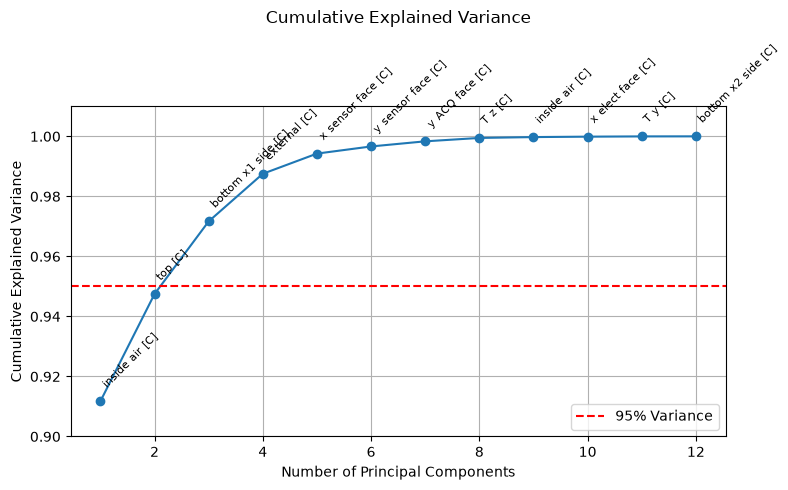

In [348]:
cum_var = np.cumsum(explained)

# Dominant (highest-|loading|) original feature for each PC
top_features = [pca_features[np.argmax(np.abs(pca.components_[i]))] for i in range(len(explained))]
print(top_features)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o')
ax.axhline(y=0.95, color='red', linestyle='--', label='95% Variance')

for x, y, feat in zip(range(1, len(cum_var)+1), cum_var, top_features):
    ax.annotate(feat, (x, y), textcoords="offset points", xytext=(0, 8),
                fontsize=8, rotation=45, ha='left', va='bottom')

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Cumulative Explained Variance", pad=60)
ax.set_ylim(0.9, 1.01)
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

In [349]:
uninterrupted_df["error_array"] = uninterrupted_df[[ "x [m/s2]", "y [m/s2]", "z [m/s2]"]].values.tolist()
uninterrupted_df["error_array"].head(10)

1967042    [1.523687473304808e-05, 2.6551772364558212e-05...
1967043    [1.4840056551229913e-05, 2.6494954182740057e-0...
1967044    [1.4779556551229904e-05, 2.6426454182740016e-0...
1967045    [1.455005655122991e-05, 2.6461954182740026e-05...
1967046    [1.4421556551229905e-05, 2.629295418274004e-05...
1967047    [1.4431056551229914e-05, 2.6004454182740053e-0...
1967048    [1.4433556551229933e-05, 2.662845418274003e-05...
1967049    [1.486405655122992e-05, 2.6042954182740062e-05...
1967050    [1.416705655122991e-05, 2.660895418274003e-05,...
1967051    [1.3704556551229912e-05, 2.6328454182740055e-0...
Name: error_array, dtype: object

In [350]:
reduced_feature_df = uninterrupted_df[["error_array", *top_features[0:7]]]
reduced_feature_df.reset_index(drop=True, inplace=True)
reduced_feature_df.head(10)

,error_array,inside air [C],top [C],bottom x1 side [C],external [C],x sensor face [C],y sensor face [C],y ACQ face [C]
0,"[1.523687473304808e-05, 2.6551772364558212e-05...",21.021573,21.235692,20.454394,20.779997,20.840455,21.149750,20.775696
1,"[1.4840056551229913e-05, 2.6494954182740057e-0...",21.021625,21.235638,20.454457,20.784550,20.839291,21.149834,20.775706
2,"[1.4779556551229904e-05, 2.6426454182740016e-0...",21.021522,21.234698,20.454648,20.789950,20.838908,21.149494,20.775798
3,"[1.455005655122991e-05, 2.6461954182740026e-05...",21.021452,21.233754,20.454957,20.790000,20.838893,21.149110,20.775955
4,"[1.4421556551229905e-05, 2.629295418274004e-05...",21.021507,21.232783,20.455168,20.790000,20.838885,21.148781,20.775926
5,"[1.4431056551229914e-05, 2.6004454182740053e-0...",21.021581,21.231861,20.455435,20.787250,20.839091,21.148548,20.775972
6,"[1.4433556551229933e-05, 2.662845418274003e-05...",21.021564,21.230930,20.455811,20.788750,20.839236,21.148320,20.776113
7,"[1.486405655122992e-05, 2.6042954182740062e-05...",21.021545,21.230071,20.456032,20.792625,20.839469,21.147980,20.776156
8,"[1.416705655122991e-05, 2.660895418274003e-05,...",21.021564,21.229101,20.456352,20.801875,20.839468,21.147686,20.776228
9,"[1.3704556551229912e-05, 2.6328454182740055e-0...",21.021675,21.228209,20.456736,20.807750,20.839564,21.147560,20.776275


**Create chronological train/test split**

In [351]:
X = np.array(reduced_feature_df.drop(columns=['error_array']))
y = np.array(reduced_feature_df['error_array'].tolist())

# Split chronologically as the data is time dependent
split_idx = int(len(reduced_feature_df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 597012, Test size: 149253


**Standardize predictors**

In [352]:
from sklearn.preprocessing import StandardScaler

X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Compare predictor distributions before and after scaling**

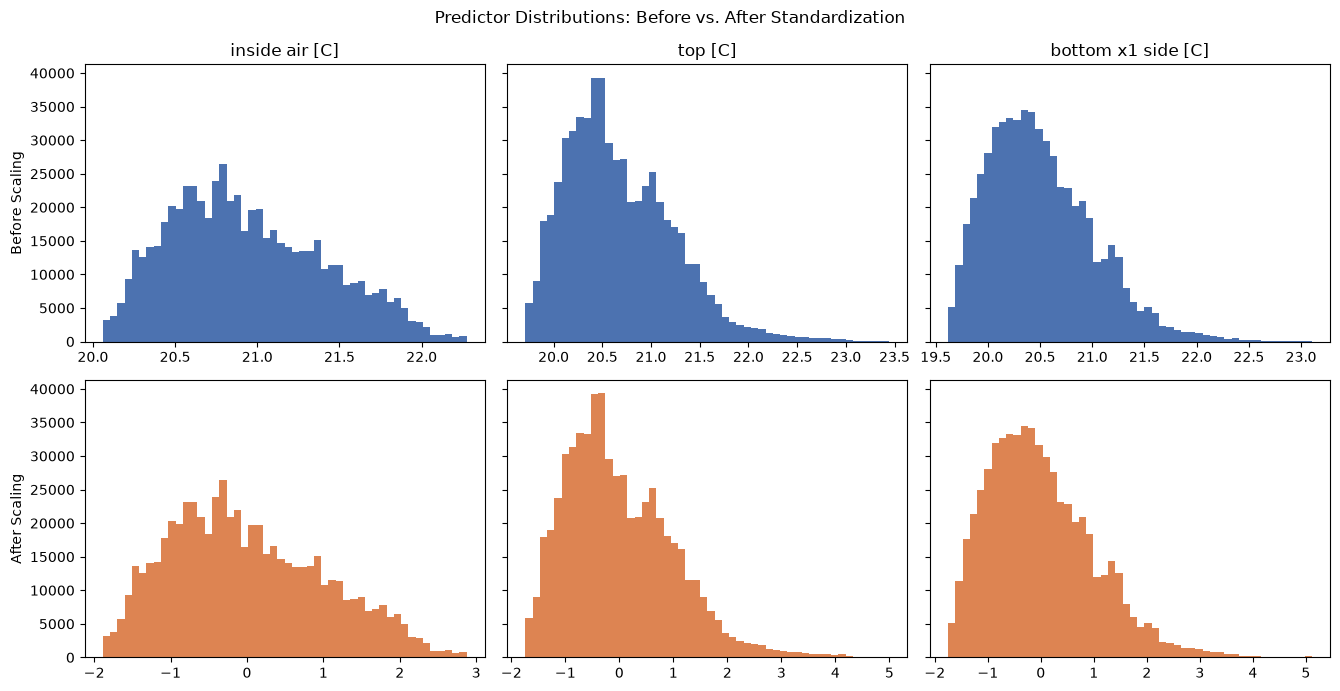

In [353]:
feature_names = list(reduced_feature_df.drop(columns=['error_array']).columns)
subset_idxs = [0, 1, 2]  # first 3 predictors

fig, axes = plt.subplots(2, len(subset_idxs), figsize=(4.5 * len(subset_idxs), 7), sharey='row')

for col, idx in enumerate(subset_idxs):
    name = feature_names[idx]

    axes[0, col].hist(X_train_raw[:, idx], bins=50, color='#4C72B0')
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel('Before Scaling' if col == 0 else '')

    axes[1, col].hist(X_train[:, idx], bins=50, color='#DD8452')
    axes[1, col].set_ylabel('After Scaling' if col == 0 else '')

fig.suptitle("Predictor Distributions: Before vs. After Standardization")
plt.tight_layout()
plt.show()